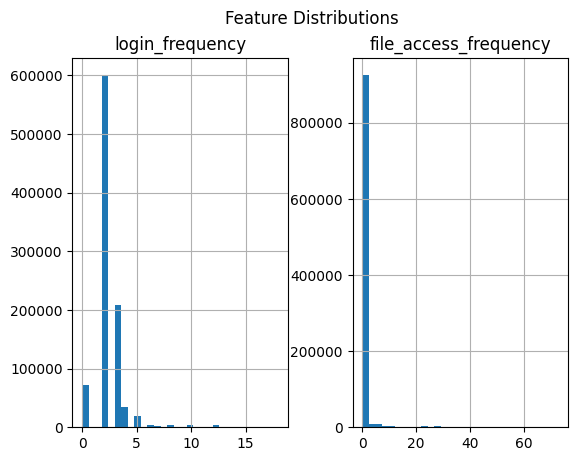

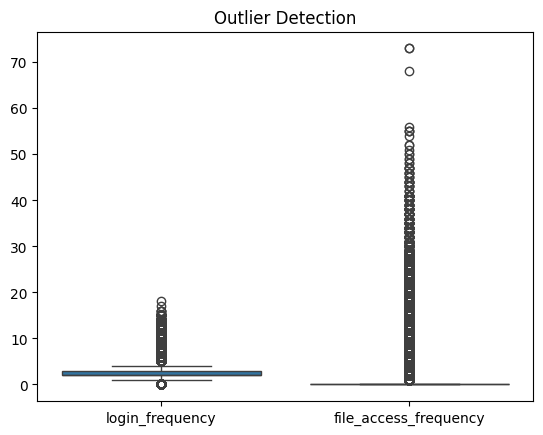

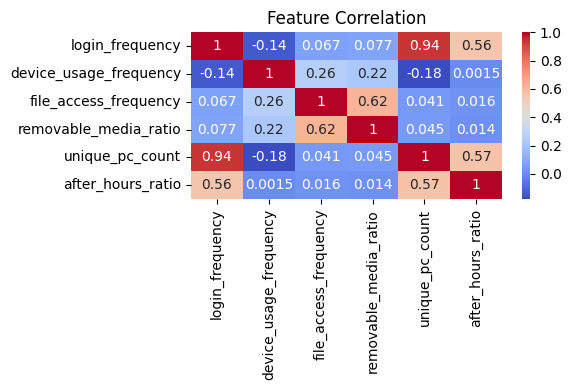

Explained Variance Ratio: [0.40400584 0.2952672 ]
Total Variance Explained: 0.6992730453819336


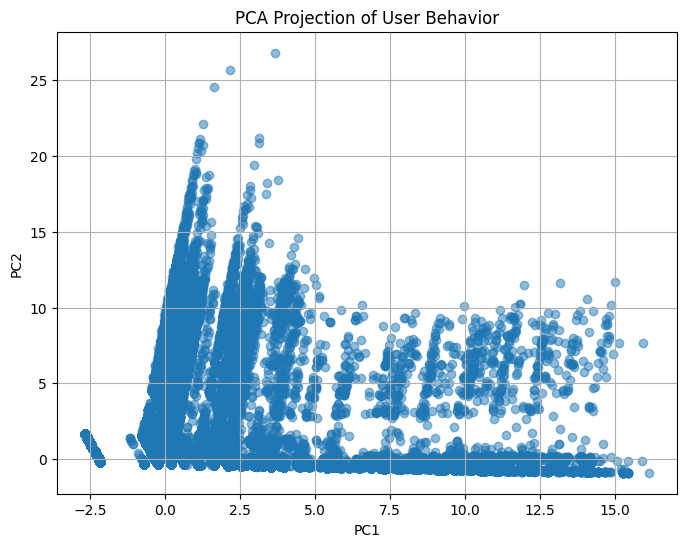

In [ ]:
# ===========================
# 3b EDA and Feature Engineering
# ===========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras import layers, models

# ================================
# EXPLORATORY DATA ANALYSIS
# ================================

# Distribution plots
merged_features[['login_frequency','file_access_frequency']].hist(bins=30)
plt.suptitle("Feature Distributions")
plt.show()

# Boxplot (outlier detection)
sns.boxplot(data=merged_features[['login_frequency','file_access_frequency']])
plt.title("Outlier Detection")
plt.show()

# Correlation heatmap
features = ['login_frequency','device_usage_frequency','file_access_frequency',
            'removable_media_ratio','unique_pc_count','after_hours_ratio']

plt.figure(figsize=(6, 4)) # Adjusted figure size to be smaller
corr = merged_features[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.tight_layout() # Added to ensure all elements fit
plt.show()

# ================================
# FEATURE ENGINEERING
# ================================

# Convert datetime if needed
logon_df['date'] = pd.to_datetime(logon_df['date'])

# Extract hour for behavioral feature
logon_df['hour'] = logon_df['date'].dt.hour

# After-hours login (before 6AM or after 8PM)
logon_df['after_hours_login'] = logon_df['hour'].apply(lambda x: 1 if x < 6 or x > 20 else 0)

# ================================
# AGGREGATE FEATURES
# ================================

# Logon features
logon_features = logon_df.groupby(['user','date_day']).agg({
    'activity':'count',
    'pc':'nunique',
    'after_hours_login':'mean'
}).rename(columns={
    'activity':'login_frequency',
    'pc':'unique_pc_count',
    'after_hours_login':'after_hours_ratio'
}).reset_index()

# Device features
device_features = device_df.groupby(['user','date_day']).agg({
    'activity':'count'
}).rename(columns={
    'activity':'device_usage_frequency'
}).reset_index()

# File features
file_features = file_df.groupby(['user','date_day']).agg({
    'activity':'count',
    'to_removable_media':'mean'
}).rename(columns={
    'activity':'file_access_frequency',
    'to_removable_media':'removable_media_ratio'
}).reset_index()

# ================================
# MERGE DATASETS
# ================================
merged_features = logon_features.merge(
    device_features, on=['user','date_day'], how='outer'
).merge(
    file_features, on=['user','date_day'], how='outer'
)

merged_features.fillna(0, inplace=True)

# ================================
# PCA
# ================================
X = merged_features[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title("PCA Projection of User Behavior")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()